In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### 1. LOADING DATA


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AI_work/ims/Data Mining/Chronic Kidney Disease (CKD) Clinical Dataset/Training_CKD_dataset.csv")

print(f"Shape: {df.shape}")
# print("\nOriginal Target Distribution:")
# print(df.value_counts())

Shape: (21000, 36)


In [ ]:
df.head(3)

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,Urine_Albumin,...,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney,Target_Binary
0,29,1,28,97,69,99,0,12,95,6,...,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes,0
1,43,0,18,165,100,67,5,87,28,318,...,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No,1
2,77,0,32,116,63,101,0,16,100,1,...,9.114854,246,299,4,7.083558,No,No,Yes,No,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    21000 non-null  object 
 1   Age                       21000 non-null  int64  
 2   Gender                    21000 non-null  int64  
 3   BMI                       21000 non-null  int64  
 4   Systolic_BP               21000 non-null  int64  
 5   Diastolic_BP              21000 non-null  int64  
 6   Heart_Rate                21000 non-null  int64  
 7   Serum_Creatinine          21000 non-null  int64  
 8   Blood_Urea_Nitrogen       21000 non-null  int64  
 9   eGFR                      21000 non-null  int64  
 10  Urine_Albumin             21000 non-null  int64  
 11  Urine_Protein             21000 non-null  int64  
 12  Albumin_Creatinine_Ratio  21000 non-null  int64  
 13  Urine_Specific_Gravity    21000 non-null  float64
 14  Sodium

In [ ]:
df.describe()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,Urine_Albumin,...,WBC_Count,Platelet_Count,Packed_Cell_Volume,Blood_Glucose_Random,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,...,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,51.951905,0.500619,25.977571,113.497619,75.280857,84.280714,0.629571,21.682048,91.426095,59.986905,...,7493.323000,300422.551571,42.167238,134.330524,99.473762,6.998247,214.411762,199.511571,3.598048,6.507856
std,18.796090,0.500012,4.890439,19.151820,12.106952,14.387748,1.482399,20.800122,26.787045,136.148540,...,2019.807219,86546.236256,5.496877,37.623833,17.300907,1.736593,37.451581,58.167742,0.764034,0.865395
min,20.000000,0.000000,18.000000,90.000000,60.000000,60.000000,0.000000,7.000000,5.000000,0.000000,...,4000.000000,150022.000000,20.000000,70.000000,70.000000,4.000855,150.000000,100.000000,1.000000,5.000065
25%,36.000000,0.000000,22.000000,99.000000,66.000000,72.000000,0.000000,11.000000,89.000000,6.000000,...,5738.000000,225571.000000,40.000000,102.000000,84.000000,5.509804,182.000000,149.000000,3.000000,5.757357
50%,52.000000,1.000000,26.000000,110.000000,73.000000,84.000000,0.000000,15.000000,99.000000,13.000000,...,7504.000000,300718.000000,43.000000,134.000000,99.000000,7.002234,214.000000,199.000000,4.000000,6.520847
75%,68.000000,1.000000,30.000000,120.000000,80.000000,97.000000,1.000000,20.000000,109.000000,20.000000,...,9234.000000,375397.250000,46.000000,167.000000,114.000000,8.501457,247.000000,250.000000,4.000000,7.254656
max,84.000000,1.000000,34.000000,189.000000,119.000000,109.000000,9.000000,149.000000,119.000000,999.000000,...,10999.000000,449942.000000,49.000000,199.000000,129.000000,9.999904,279.000000,299.000000,4.000000,7.999568


# 2. BINARIZING THE TARGET FEATURE


In [ ]:
# print("\n" + "=" * 55)
# print("STEP 2 — Binarizing Target")
# print("=" * 55)

df['Target_Binary'] = df['Target'].apply(
    lambda x: 0 if x == 'Healthy Kidney' else 1
)
df.drop(columns=['Target'], inplace=True)

print("0 = Healthy Kidney")
print("1 = Non-Healthy (CKD any stage)")
print("\nBinary Target Distribution:")
print(df['Target_Binary'].value_counts())

0 = Healthy Kidney
1 = Non-Healthy (CKD any stage)

Binary Target Distribution:
Target_Binary
0    15744
1     5256
Name: count, dtype: int64


## eGFR vs. Serum Creatinine


In clinical practice, eGFR (estimated Glomerular Filtration Rate) and Creatinine are the most important indicators of kidney function.

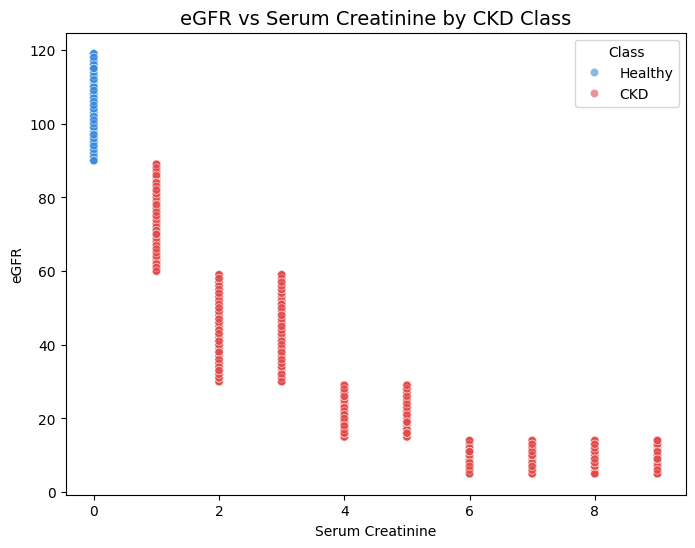

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Serum_Creatinine',
    y='eGFR',
    hue='Target_Binary',
    data=df,
    palette={0: '#378ADD', 1: '#E24B4A'},  # explicit mapping
    alpha=0.6
)
plt.title('eGFR vs Serum Creatinine by CKD Class', fontsize=14)
plt.xlabel('Serum Creatinine')
plt.ylabel('eGFR')

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Healthy', 'CKD'], title='Class')
plt.show()

## Hemoglobin and Kidney Health


Kidneys produce erythropoietin, which helps make red blood cells. Low hemoglobin (anemia) is a common complication of CKD.

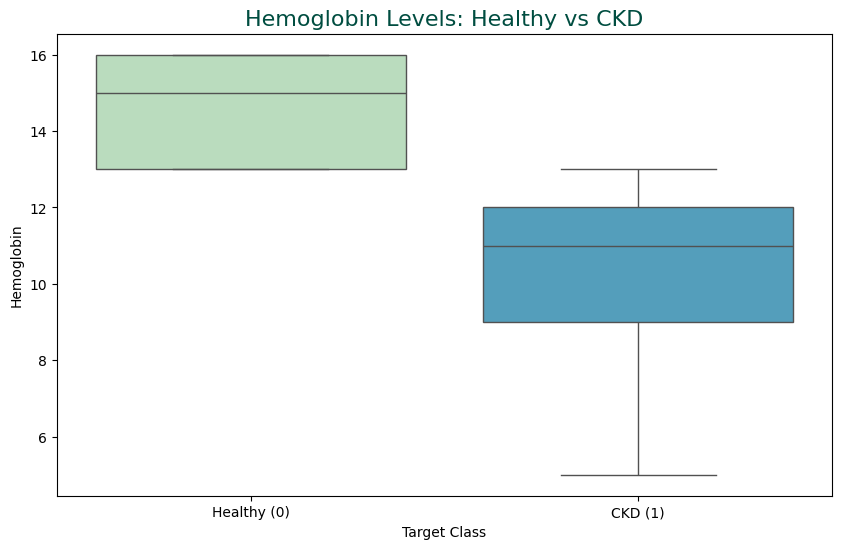

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Target_Binary', y='Hemoglobin', data=df, palette="GnBu"
)
plt.xticks([0, 1], ['Healthy (0)', 'CKD (1)'])
plt.title('Hemoglobin Levels: Healthy vs CKD', fontsize=16, color='#004d40')
plt.xlabel('Target Class')
plt.ylabel('Hemoglobin')
plt.show()

## Correlation Heatmap

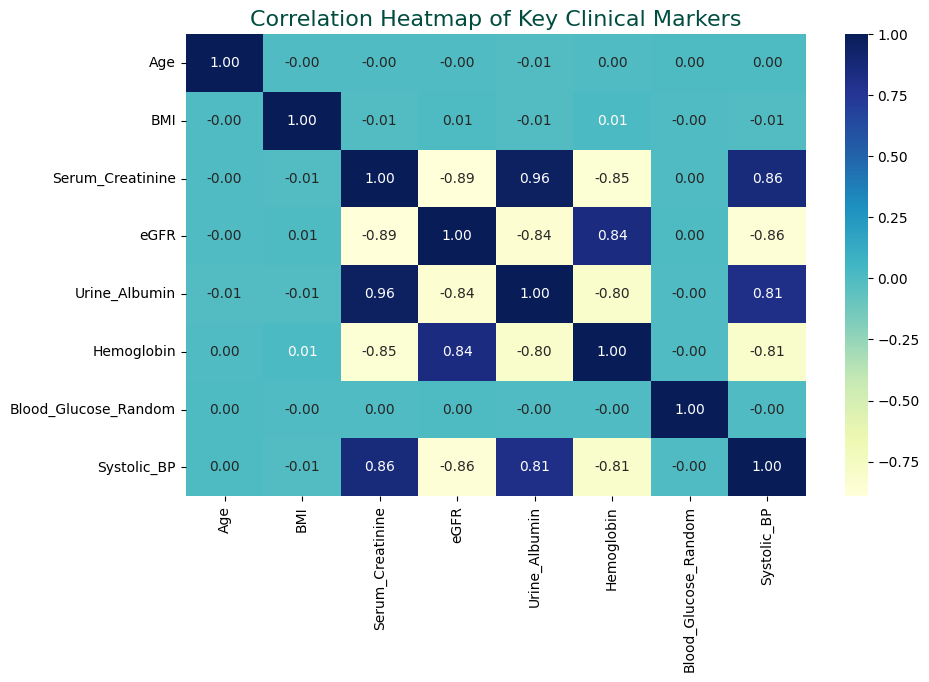

In [ ]:
important_cols = ['Age', 'BMI', 'Serum_Creatinine', 'eGFR', 'Urine_Albumin',
                  'Hemoglobin', 'Blood_Glucose_Random', 'Systolic_BP']
plt.figure(figsize=(10, 6))
sns.heatmap(df[important_cols].corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap of Key Clinical Markers', fontsize=16, color='#004d40')
plt.show()

# 3. UNDERSAMPLING THE MAJORITY CLASS IN INDEPENDENT VARIABLE


In [ ]:
# print("\n" + "=" * 55)
# print("STEP 3 — Undersampling Majority Class")
# print("=" * 55)

healthy     = df[df['Target_Binary'] == 0]
non_healthy = df[df['Target_Binary'] == 1]

# Undersample healthy to 6000
n_healthy_target = min(6000, len(healthy))
healthy_sampled  = healthy.sample(n=n_healthy_target, random_state=42)

df_balanced = pd.concat([healthy_sampled, non_healthy]).reset_index(drop=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Healthy samples kept  : {len(healthy_sampled)}")
print(f"Non-Healthy samples   : {len(non_healthy)}")
print(f"Total balanced dataset: {len(df_balanced)}")
print(f"\nClass ratio  — Healthy: {len(healthy_sampled)/len(df_balanced)*100:.1f}%  |  Non-Healthy: {len(non_healthy)/len(df_balanced)*100:.1f}%")

Healthy samples kept  : 6000
Non-Healthy samples   : 5256
Total balanced dataset: 11256

Class ratio  — Healthy: 53.3%  |  Non-Healthy: 46.7%


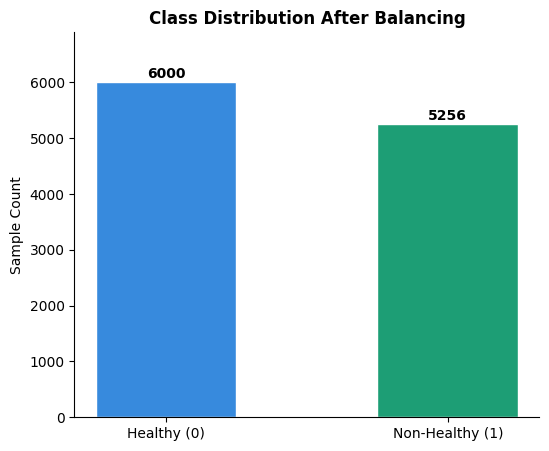

In [ ]:
plt.figure(figsize=(6, 5))

labels = ['Healthy (0)', 'Non-Healthy (1)']
counts = [len(healthy_sampled), len(non_healthy)]
colors = ['#378ADD', '#1D9E75']

bars = plt.bar(labels, counts, color=colors, width=0.5, edgecolor='white')

plt.title('Class Distribution After Balancing', fontweight='bold')
plt.ylabel('Sample Count')

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             str(count), ha='center', fontweight='bold')

plt.ylim(0, max(counts) * 1.15)
plt.gca().spines[['top','right']].set_visible(False)

plt.show()

# 4. PREPROCESSING


In [ ]:
# print("\n" + "=" * 55)
# print("STEP 4 — Preprocessing")
# print("=" * 55)


# 4a. Encode binary Yes/No columns
df_balanced = df_balanced.copy()

binary_cols = ['Diabetes', 'Hypertension', 'Smoking_Status', 'Family_History_Kidney']
for col in binary_cols:
    if col in df_balanced.columns:
        df_balanced.loc[:, col] = df_balanced[col].map({'Yes': 1, 'No': 0})
        print(f"Encoded: {col}")

Encoded: Diabetes
Encoded: Hypertension
Encoded: Smoking_Status
Encoded: Family_History_Kidney


### Finding correlations of the Features

In [ ]:
corr = df_balanced.corr()['Target_Binary'].sort_values(ascending=False)
print(corr)

Target_Binary               1.000000
Diastolic_BP                0.829354
Systolic_BP                 0.813905
Phosphorus                  0.724920
Serum_Creatinine            0.674718
Blood_Urea_Nitrogen         0.667259
Urine_Albumin               0.576368
Urine_Protein               0.566222
Albumin_Creatinine_Ratio    0.540319
Potassium                   0.443234
Hypertension                0.018352
Smoking_Status              0.017380
Age                         0.017295
Diabetes                    0.017191
Triglycerides               0.005772
Gender                      0.005770
Fasting_Glucose             0.004535
Blood_Glucose_Random        0.004289
WBC_Count                   0.003380
Chloride                    0.003025
Heart_Rate                  0.001456
BMI                        -0.002090
RBC_Count                  -0.002562
Sodium                     -0.004784
Family_History_Kidney      -0.007314
Cholesterol                -0.007441
Platelet_Count             -0.011356
T

In [ ]:
drop_cols = [
    'Hemoglobin',
    'Bicarbonate',
    'Packed_Cell_Volume',
    'Potassium',
    'eGFR',
    'Serum_Creatinine',
    'Blood_Urea_Nitrogen',
    'Urine_Albumin',
    'Urine_Protein',
    'Albumin_Creatinine_Ratio',
    'Systolic_BP',
    'Diastolic_BP',
    'Serum_Albumin',
]
df_balanced = df_balanced.drop(columns=drop_cols)

In [ ]:
# 4c. Separate features and target
y = df_balanced['Target_Binary']
X = df_balanced.drop(columns=['Target_Binary'])

print(f"\nFinal feature count: {X.shape[1]}")
print(f"Final sample count : {X.shape[0]}")


Final feature count: 22
Final sample count : 11256


# 5. SPLITING Using K-fold


In [ ]:
K   = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )
# # print("\n" + "=" * 55)
# # print("STEP 5 — Train/Test Split (80/20 stratified)")
# # print("=" * 55)
# print(f"Training samples : {X_train.shape[0]}")
# print(f"Testing  samples : {X_test.shape[0]}")


# 6. FEATURE SCALING


In [ ]:
# scaler  = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test  = scaler.transform(X_test)
# print("\nStandardScaler applied (fit on train, transform on test)")


StandardScaler applied (fit on train, transform on test)


# 7. MODEL TRAINING


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'))
    ]),
}

scoring = ['accuracy', 'precision', 'recall', 'f1']
results = {}

for name, pipe in models.items():
    cv = cross_validate(pipe, X, y, cv=skf, scoring=scoring)
    results[name] = {m: cv[f'test_{m}'] for m in ['accuracy','precision','recall','f1']}
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.


In [ ]:
# Summary table
metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : f"{v['accuracy'].mean():.4f}",
        'Precision': f"{v['precision'].mean():.4f}",
        'Recall'   : f"{v['recall'].mean():.4f}",
        'F1 Score' : f"{v['f1'].mean():.4f}",
        # 'AUC-ROC'  : f"{v['roc_auc'].mean():.4f}",
    }
    for name, v in results.items()
}).T
print(metrics_df.to_string())

                    Accuracy Precision  Recall F1 Score
Logistic Regression   0.8861    1.0000  0.7561   0.8611
Decision Tree         0.8846    0.9943  0.7572   0.8597


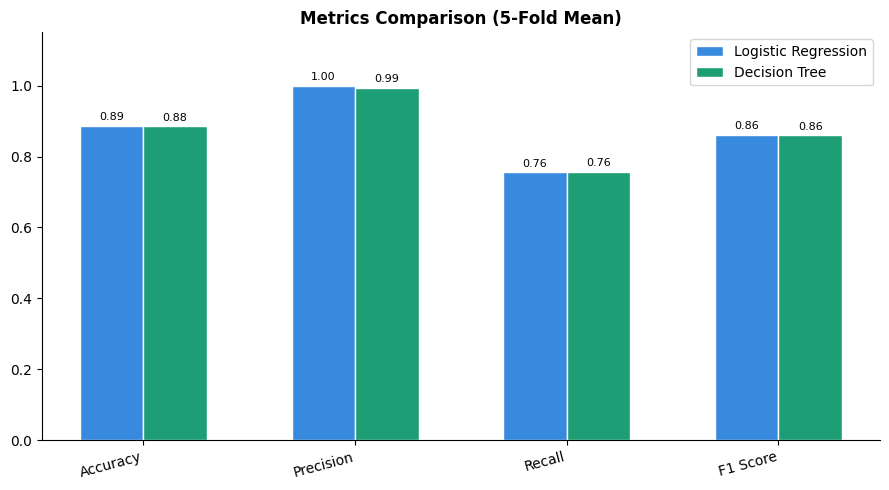

In [ ]:
# ── Metrics Bar Chart ────────────────────────────────────
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metric_names))
w, colors = 0.3, ['#378ADD', '#1D9E75']

plt.figure(figsize=(9, 5))
for i, (name, v) in enumerate(results.items()):
    vals = [v['accuracy'].mean(), v['precision'].mean(),
            v['recall'].mean(), v['f1'].mean().mean()]
    bars = plt.bar(x + i*w, vals, w, label=name, color=colors[i], edgecolor='white')
    for p in bars:
        plt.annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                     ha='center', va='bottom', fontsize=8)

plt.xticks(x + w/2, metric_names, rotation=15, ha='right')
plt.ylim(0, 1.15)
plt.title('Metrics Comparison (5-Fold Mean)', fontweight='bold')
plt.legend()
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# 8. EVALUATING RESULTS


### Confusion Matrix and Classification Report


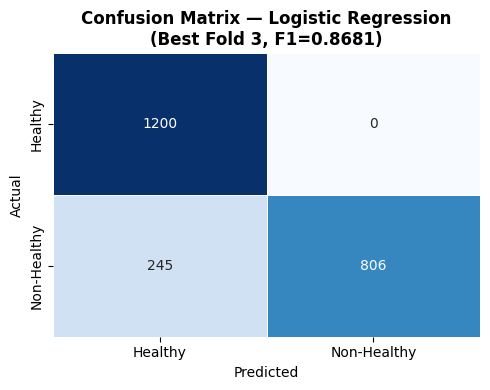


Classification Report — Logistic Regression (Best Fold 3):
              precision    recall  f1-score   support

     Healthy       0.83      1.00      0.91      1200
 Non-Healthy       1.00      0.77      0.87      1051

    accuracy                           0.89      2251
   macro avg       0.92      0.88      0.89      2251
weighted avg       0.91      0.89      0.89      2251



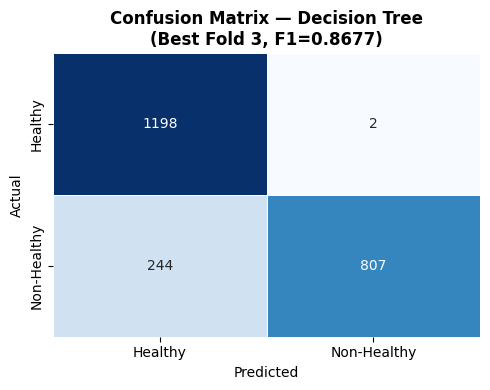


Classification Report — Decision Tree (Best Fold 3):
              precision    recall  f1-score   support

     Healthy       0.83      1.00      0.91      1200
 Non-Healthy       1.00      0.77      0.87      1051

    accuracy                           0.89      2251
   macro avg       0.91      0.88      0.89      2251
weighted avg       0.91      0.89      0.89      2251



In [ ]:
# ── Confusion Matrix (best F1 fold per model) ────────────
folds = list(skf.split(X, y))

for i, (name, pipe) in enumerate(models.items()):
    best_fold = results[name]['f1'].argmax()
    _, test_idx = folds[best_fold]

    # Refit best fold pipeline to get predictions
    train_idx = folds[best_fold][0]
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred_fold = pipe.predict(X.iloc[test_idx])
    y_test_fold = y.iloc[test_idx]

    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test_fold, y_pred_fold)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy', 'Non-Healthy'],
                yticklabels=['Healthy', 'Non-Healthy'],
                linewidths=0.5, cbar=False)
    plt.title(f'Confusion Matrix — {name}\n(Best Fold {best_fold+1}, F1={results[name]["f1"][best_fold]:.4f})',
              fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    print(f"\nClassification Report — {name} (Best Fold {best_fold+1}):")
    print(classification_report(y_test_fold, y_pred_fold,
          target_names=['Healthy', 'Non-Healthy']))